[INFO] CUDA device: Tesla T4, capability=sm_75
[INFO] Global Config
{
  "data_root": "/kaggle/input/datasets/chonlanawawa/bloodclot-segement/bloodclot_seg/split_by_patient_task",
  "task": "ischemia",
  "output_dir": "/kaggle/working/outputs_ischemia_dual_models_fixed",
  "subtypes_to_train": [
    "AISD",
    "CPAISD"
  ],
  "use_25d": true,
  "in_channels": 3,
  "image_size": [
    256,
    256
  ],
  "img_divisor": 255.0,
  "positive_cases_only_train": true,
  "positive_cases_only_val": true,
  "positive_cases_only_test": true,
  "include_neighbor_slices": 2,
  "max_negative_ratio_train": 0.15,
  "max_negative_ratio_val": 0.3,
  "max_negative_ratio_test": 0.3,
  "seed": 42,
  "device": "cuda",
  "epochs": 30,
  "batch_size": 8,
  "num_workers": 2,
  "lr": 5e-05,
  "weight_decay": 0.0005,
  "grad_clip": 1.0,
  "amp": true,
  "dice_weight": 0.85,
  "bce_weight": 0.15,
  "fixed_train_val_threshold": 0.5,
  "threshold_candidates": [
    0.1,
    0.15000000000000002,
    0.20000000000000

100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s]


[DEBUG][CPAISD] model conv1 shape: (64, 3, 7, 7)
[INFO] Loading RadImageNet checkpoint from: /kaggle/input/datasets/chonlanawawa/radimagenet/RadImageNet_pytorch/DenseNet121.pt
[WARN] Matched encoder tensors loaded: 0
[WARN] Keeping current encoder init.
[INFO][CPAISD] Encoder frozen for first 3 epoch(s)
[INFO][CPAISD] Start training
[INFO][CPAISD] Fixed train/val threshold during training: 0.50
[EPOCH 1][CPAISD] train_loss=0.829225 train_dice@0.50=0.237786 val_loss=0.825918 val_slice_dice=0.240779 val_global_dice=0.308829 val_case_mean=0.284101±0.115441 lr=3.000000e-05
[INFO][CPAISD] New best saved: epoch=1, val_case_mean=0.284101, th=0.50
[EPOCH 2][CPAISD] train_loss=0.792977 train_dice@0.50=0.302915 val_loss=0.795397 val_slice_dice=0.297203 val_global_dice=0.377296 val_case_mean=0.340570±0.139893 lr=3.000000e-05
[INFO][CPAISD] New best saved: epoch=2, val_case_mean=0.340570, th=0.50
[EPOCH 3][CPAISD] train_loss=0.771152 train_dice@0.50=0.329512 val_loss=0.786519 val_slice_dice=0.3038

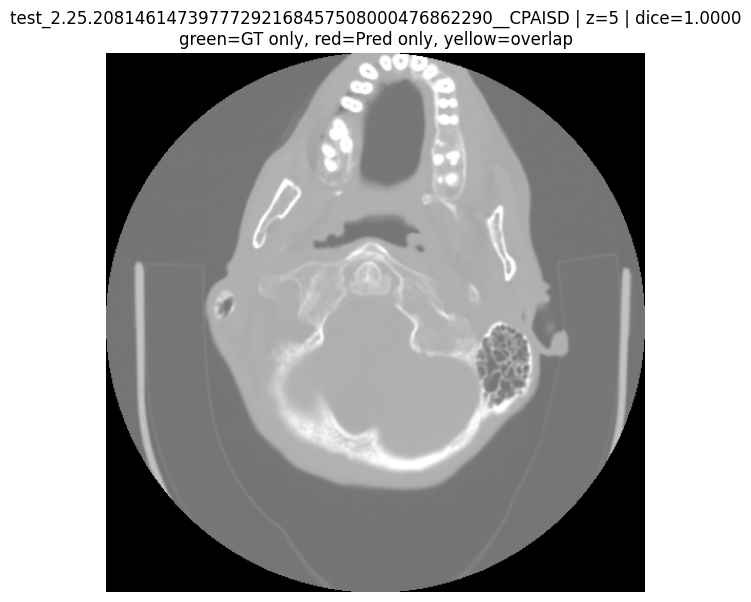

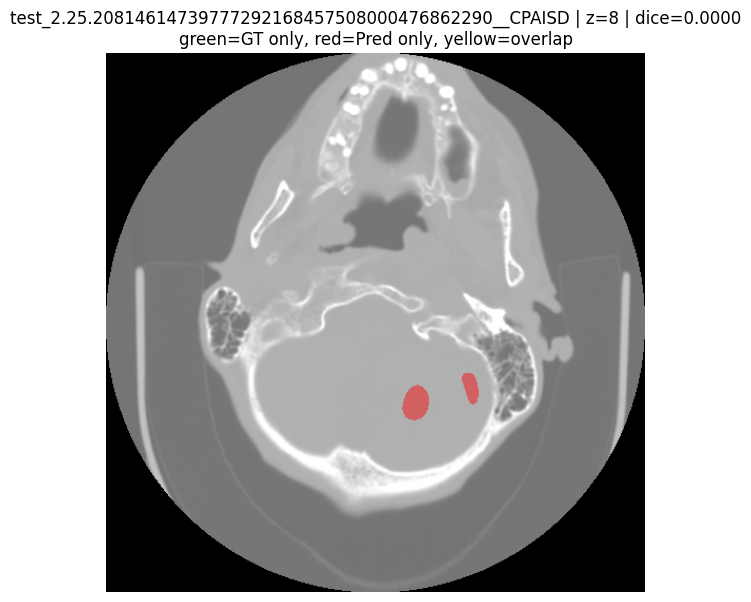

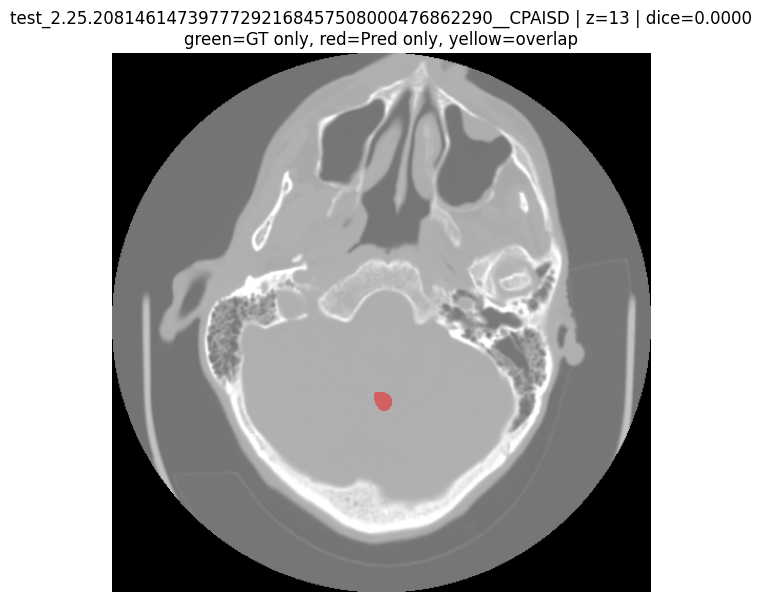

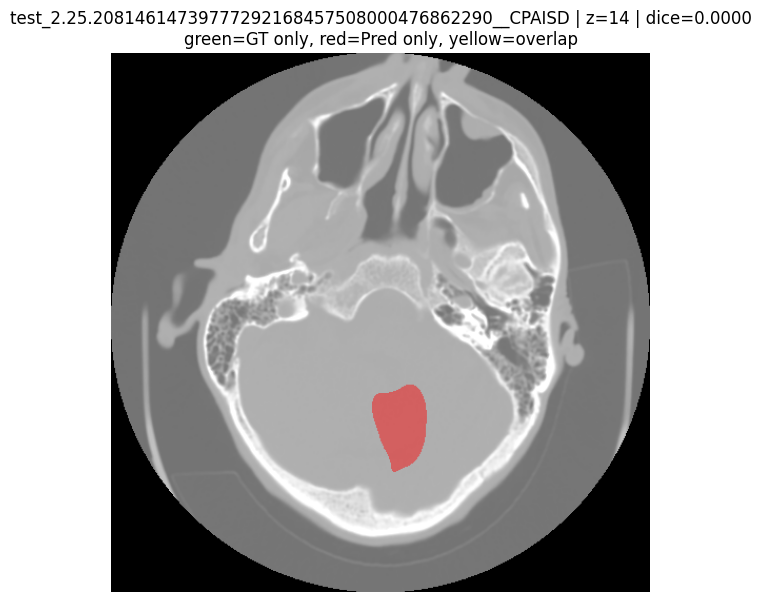

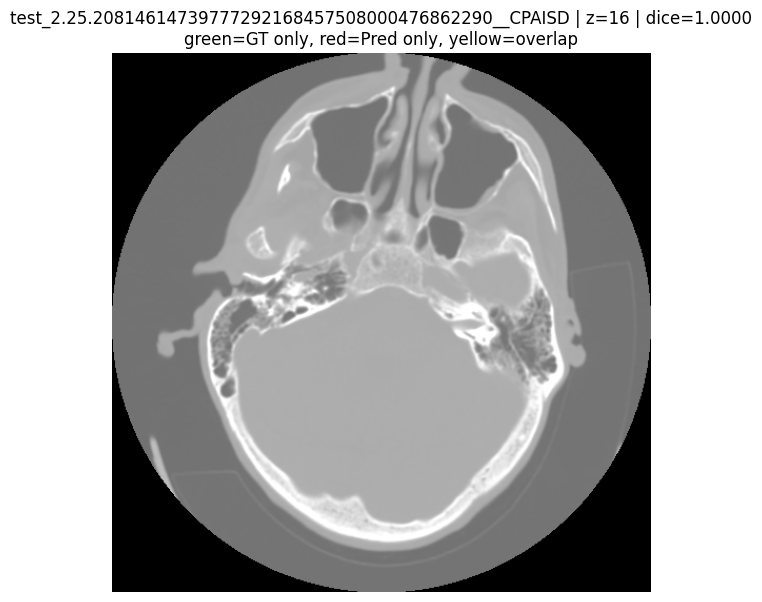

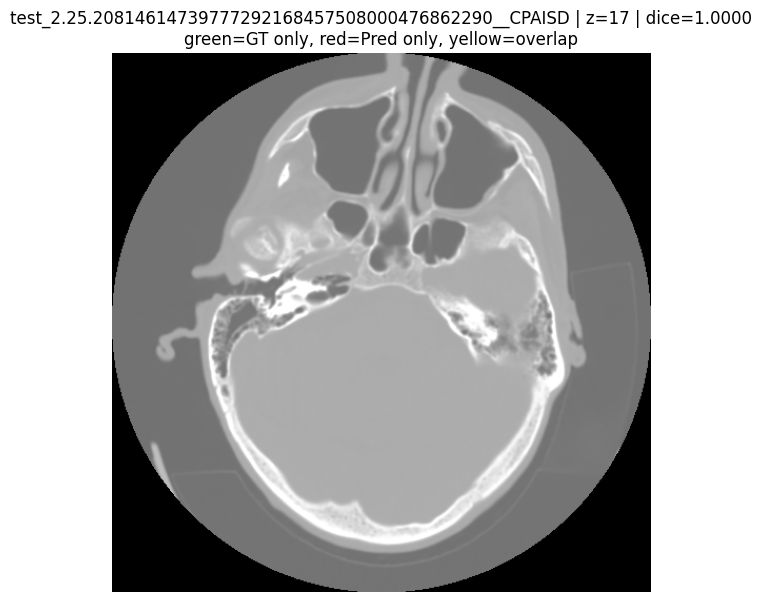

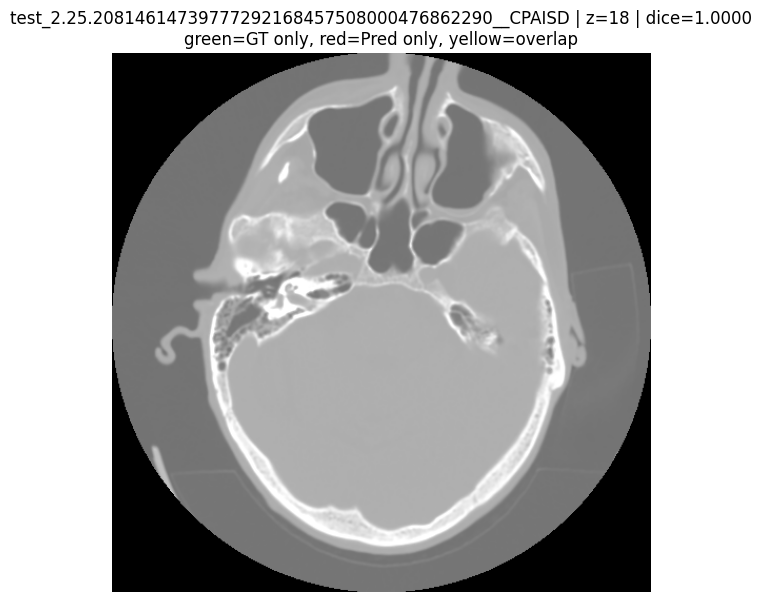

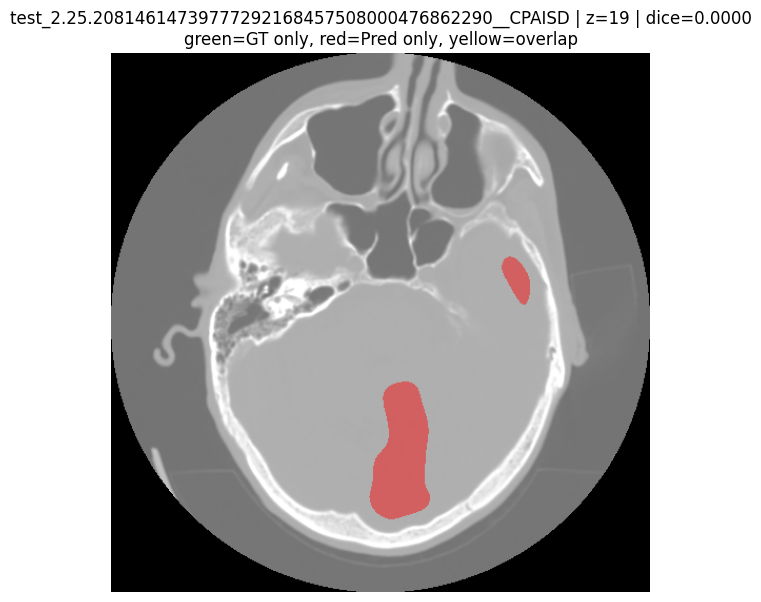

[INFO][CPAISD] Test overlays saved to: /kaggle/working/outputs_ischemia_dual_models_fixed/ischemia_CPAISD_unet_resnet50_radimagenet/test_overlays_best
[INFO][CPAISD] Done.
[INFO] All subtype training finished.


In [1]:
# =========================================================
# FULL FIXED PIPELINE: ISCHEMIA -> AISD + CPAISD SEPARATE MODELS
# - same architecture for both subtypes
# - subtype split from case suffix: __AISD / __CPAISD
# - robust folder discovery
# - supports multiple mask PNGs per slice (important for CPAISD)
# - subtype-specific training settings
# - saves separate outputs for AISD and CPAISD
# =========================================================

import os
import re
import json
import math
import random
from dataclasses import dataclass, asdict, replace
from pathlib import Path
from typing import List, Dict, Tuple, Optional, Any

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy import ndimage

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
@dataclass
class Config:
    # dataset
    data_root: str = "/kaggle/input/datasets/chonlanawawa/bloodclot-segement/bloodclot_seg/split_by_patient_task"
    task: str = "ischemia"
    output_dir: str = "/kaggle/working/outputs_ischemia_dual_models_fixed"

    # targets
    subtypes_to_train: Tuple[str, ...] = ("AISD", "CPAISD")

    # input
    use_25d: bool = True
    in_channels: int = 3
    image_size: Tuple[int, int] = (256, 256)
    img_divisor: float = 255.0

    # sampling
    positive_cases_only_train: bool = True
    positive_cases_only_val: bool = True
    positive_cases_only_test: bool = True
    include_neighbor_slices: int = 2
    max_negative_ratio_train: float = 0.15
    max_negative_ratio_val: float = 0.30
    max_negative_ratio_test: float = 0.30

    # optimization
    seed: int = 42
    device: str = "cpu"
    epochs: int = 30
    batch_size: int = 8
    num_workers: int = 2
    lr: float = 5e-5
    weight_decay: float = 5e-4
    grad_clip: float = 1.0
    amp: bool = False

    # loss / metric
    dice_weight: float = 0.85
    bce_weight: float = 0.15
    fixed_train_val_threshold: float = 0.5
    threshold_candidates: Tuple[float, ...] = tuple(np.arange(0.10, 0.91, 0.05).tolist())
    threshold_tune_metric: str = "case_mean"  # "slice_mean", "global", "case_mean"

    # pretrained
    use_torchvision_imagenet_fallback: bool = True
    radimagenet_weights_path: Optional[str] = "/kaggle/input/datasets/chonlanawawa/radimagenet/RadImageNet_pytorch/DenseNet121.pt"
    freeze_encoder_epochs: int = 3

    # scheduler / early stop
    patience: int = 10
    scheduler_patience: int = 5

    # postprocess
    use_postprocess: bool = False
    pp_min_area: int = 16
    pp_keep_top_k: Optional[int] = None
    pp_do_open: bool = False
    pp_do_close: bool = True
    pp_structure_size: int = 3

    # save / vis
    save_test_predictions: bool = True
    save_test_overlays: bool = True
    show_inline_test_overlays: bool = True
    max_inline_overlays: int = 8

    # regularization
    decoder_dropout: float = 0.15

    # debug
    verbose_discovery: bool = True


# =========================================================
# UTIL
# =========================================================
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)


def save_json(obj, path: str):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)


def read_png_gray(path: str) -> np.ndarray:
    img = Image.open(path).convert("L")
    return np.array(img)


def resize_2d_np(x: np.ndarray, out_hw: Tuple[int, int], is_mask: bool = False) -> np.ndarray:
    xt = torch.from_numpy(x).float()
    if xt.ndim == 2:
        xt = xt.unsqueeze(0).unsqueeze(0)
    elif xt.ndim == 3:
        xt = xt.unsqueeze(0)
    else:
        raise ValueError(f"resize_2d_np expected 2D or 3D, got {x.shape}")

    mode = "nearest" if is_mask else "bilinear"
    if mode == "bilinear":
        xt = F.interpolate(xt, size=out_hw, mode=mode, align_corners=False)
    else:
        xt = F.interpolate(xt, size=out_hw, mode=mode)

    xt = xt.squeeze(0).cpu().numpy()
    return xt


def natural_sort_key(path_obj: Path):
    s = path_obj.stem
    parts = re.split(r"(\d+)", s)
    return [int(p) if p.isdigit() else p for p in parts]


def get_safe_device_and_amp():
    if not torch.cuda.is_available():
        print("[INFO] CUDA not available -> CPU")
        return "cpu", False

    try:
        name = torch.cuda.get_device_name(0)
        major, minor = torch.cuda.get_device_capability(0)
        print(f"[INFO] CUDA device: {name}, capability=sm_{major}{minor}")
        if major < 7:
            print("[WARN] GPU capability too old for current torch CUDA build -> CPU fallback")
            return "cpu", False
        return "cuda", True
    except Exception as e:
        print(f"[WARN] CUDA probe failed: {e} -> CPU fallback")
        return "cpu", False


def get_autocast_context(device: str, enabled: bool):
    return torch.amp.autocast(device_type="cuda", enabled=(enabled and device == "cuda"))


def get_grad_scaler(enabled: bool, device: str):
    if device == "cuda":
        return torch.amp.GradScaler("cuda", enabled=enabled)
    return torch.amp.GradScaler("cuda", enabled=False)


# =========================================================
# SUBTYPE PARSING
# =========================================================
def get_case_subtype(case_id: str) -> Optional[str]:
    cid = str(case_id).upper()
    if cid.endswith("__AISD"):
        return "AISD"
    if cid.endswith("__CPAISD"):
        return "CPAISD"
    return None


def filter_cases_by_subtype(cases: List[Dict], subtype: str) -> List[Dict]:
    subtype = subtype.upper()
    return [c for c in cases if str(c.get("subtype", "")).upper() == subtype]


# =========================================================
# ROBUST DATA DISCOVERY
# =========================================================
def _first_existing_dir(candidates: List[Path]) -> Optional[Path]:
    for p in candidates:
        if p.exists() and p.is_dir():
            return p
    return None


def _extract_slice_index_from_name(name: str) -> Optional[int]:
    stem = Path(name).stem
    nums = re.findall(r"\d+", stem)
    if not nums:
        return None
    # use first number group to match common slice naming like 0001.png / slice_0001.png
    return int(nums[0])


def discover_cases_png(split_root: Path, verbose: bool = True) -> List[Dict]:
    cases = []
    if not split_root.exists():
        raise FileNotFoundError(f"Split folder not found: {split_root}")

    case_dirs = sorted([x for x in split_root.iterdir() if x.is_dir()])

    if verbose:
        print(f"[DISCOVER] split_root={split_root}")
        print(f"[DISCOVER] found {len(case_dirs)} directories")

    for case_dir in case_dirs:
        case_name = case_dir.name
        if case_name.lower() in {"images", "image", "meta", "metadata", "masks", "mask", "labels", "label", "annotations"}:
            continue

        subtype = get_case_subtype(case_name)
        if subtype is None:
            if verbose:
                print(f"[DISCOVER][SKIP] {case_name}: subtype not recognized")
            continue

        img_dir = _first_existing_dir([
            case_dir / "images" / "CT",
            case_dir / "images",
            case_dir / "image" / "CT",
            case_dir / "image",
            case_dir / "CT",
        ])

        mask_dir = _first_existing_dir([
            case_dir / "masks" / "CT",
            case_dir / "masks",
            case_dir / "mask" / "CT",
            case_dir / "mask",
            case_dir / "labels" / "CT",
            case_dir / "labels",
            case_dir / "label" / "CT",
            case_dir / "label",
            case_dir / "annotations" / "CT",
            case_dir / "annotations",
        ])

        if img_dir is None:
            if verbose:
                print(f"[DISCOVER][SKIP] {case_name}: image folder not found")
            continue

        if mask_dir is None:
            if verbose:
                print(f"[DISCOVER][SKIP] {case_name}: mask folder not found")
            continue

        image_files = sorted(img_dir.glob("*.png"), key=natural_sort_key)
        mask_files = sorted(mask_dir.glob("*.png"), key=natural_sort_key)

        if len(image_files) == 0:
            if verbose:
                print(f"[DISCOVER][SKIP] {case_name}: no image pngs")
            continue

        if len(mask_files) == 0:
            if verbose:
                print(f"[DISCOVER][SKIP] {case_name}: no mask pngs")
            continue

        image_files_by_z = {}
        for ip in image_files:
            z = _extract_slice_index_from_name(ip.name)
            if z is not None:
                image_files_by_z[z] = str(ip)

        mask_files_by_z = {}
        for mp in mask_files:
            z = _extract_slice_index_from_name(mp.name)
            if z is not None:
                mask_files_by_z.setdefault(z, []).append(str(mp))

        common_z = sorted(set(image_files_by_z.keys()) & set(mask_files_by_z.keys()))

        if len(common_z) == 0:
            if verbose:
                print(f"[DISCOVER][SKIP] {case_name}: no common image/mask slice indices")
            continue

        cases.append({
            "case_id": case_name,
            "subtype": subtype,
            "z_indices": common_z,
            "image_files_by_z": {int(z): image_files_by_z[z] for z in common_z},
            "mask_files_by_z": {int(z): mask_files_by_z[z] for z in common_z},
        })

        if verbose:
            total_mask_pngs = sum(len(v) for v in mask_files_by_z.values())
            print(
                f"[DISCOVER] case={case_name} subtype={subtype} "
                f"slices={len(common_z)} total_mask_pngs={total_mask_pngs}"
            )

    subtype_count = {}
    for c in cases:
        subtype_count[c["subtype"]] = subtype_count.get(c["subtype"], 0) + 1

    if verbose:
        print(f"[DISCOVER] usable cases={len(cases)} subtype_counts={subtype_count}")

    return cases


def preload_case_meta_png(cases: List[Dict]) -> List[Dict]:
    out = []
    for c in cases:
        try:
            z_list = sorted(c["z_indices"])
            pos_slices = []
            H, W = None, None

            for z in z_list:
                merged = None
                for mp in c["mask_files_by_z"][z]:
                    m = (read_png_gray(mp) > 0).astype(np.uint8)
                    if merged is None:
                        merged = m
                        if H is None:
                            H, W = m.shape
                    else:
                        merged = np.maximum(merged, m)

                if merged is not None and merged.sum() > 0:
                    pos_slices.append(z)

            c2 = dict(c)
            c2["z"] = len(z_list)
            c2["z_indices_sorted"] = z_list
            c2["shape_zyx"] = (len(z_list), H, W)
            c2["positive_slices"] = pos_slices
            c2["is_positive_case"] = len(pos_slices) > 0
            out.append(c2)

        except Exception as e:
            print(f"[WARN] Failed meta preload for {c['case_id']}: {e}")

    return out


def build_slice_index(
    cases: List[Dict],
    positive_cases_only: bool,
    include_neighbor_slices: int,
    max_negative_ratio: float,
) -> List[Dict]:
    items = []

    for c in cases:
        if positive_cases_only and not c["is_positive_case"]:
            continue

        z_all = sorted(c["z_indices_sorted"])
        z_set = set(z_all)
        pos = set(c["positive_slices"])

        selected = set()
        for z in pos:
            selected.add(z)
            for dz in range(-include_neighbor_slices, include_neighbor_slices + 1):
                zz = z + dz
                if zz in z_set:
                    selected.add(zz)

        neg = sorted(list(z_set - selected))

        if len(neg) > 0 and max_negative_ratio > 0:
            target_neg = int(len(selected) * max_negative_ratio)
            target_neg = min(target_neg, len(neg))
            sampled_neg = random.sample(neg, target_neg) if target_neg > 0 else []
        else:
            sampled_neg = []

        final_slices = sorted(list(selected) + sampled_neg)

        if not c["is_positive_case"] and not positive_cases_only:
            final_slices = z_all

        for z_idx in final_slices:
            items.append({
                "case_id": c["case_id"],
                "subtype": c.get("subtype"),
                "image_files_by_z": c["image_files_by_z"],
                "mask_files_by_z": c["mask_files_by_z"],
                "z_idx": int(z_idx),
            })

    return items


# =========================================================
# DATASET
# =========================================================
class BloodClotPNGDataset(Dataset):
    def __init__(
        self,
        items: List[Dict],
        image_size: Tuple[int, int],
        img_divisor: float = 255.0,
        use_25d: bool = True,
        train: bool = True,
    ):
        self.items = items
        self.image_size = image_size
        self.img_divisor = img_divisor
        self.use_25d = use_25d
        self.train = train

    def __len__(self):
        return len(self.items)

    def _read_img(self, path: str) -> np.ndarray:
        x = read_png_gray(path).astype(np.float32) / self.img_divisor
        return np.clip(x, 0.0, 1.0)

    def _read_merged_mask(self, paths: List[str]) -> np.ndarray:
        merged = None
        for p in paths:
            m = (read_png_gray(p) > 0).astype(np.float32)
            if merged is None:
                merged = m
            else:
                merged = np.maximum(merged, m)
        if merged is None:
            raise ValueError("No mask paths provided for slice")
        return merged.astype(np.float32)

    def _get_slice_stack(self, image_files_by_z: Dict[int, str], z: int) -> np.ndarray:
        z_keys = sorted(image_files_by_z.keys())

        def nearest_existing(idx: int) -> int:
            if idx in image_files_by_z:
                return idx
            return min(z_keys, key=lambda k: abs(k - idx))

        if self.use_25d:
            idxs = [nearest_existing(z - 1), nearest_existing(z), nearest_existing(z + 1)]
            x = np.stack([self._read_img(image_files_by_z[i]) for i in idxs], axis=0)
        else:
            x = self._read_img(image_files_by_z[z])[None, ...]
        return x.astype(np.float32)

    def _augment(self, x: np.ndarray, y: np.ndarray):
        if random.random() < 0.5:
            x = np.flip(x, axis=2).copy()
            y = np.flip(y, axis=2).copy()

        if random.random() < 0.2:
            x = np.flip(x, axis=1).copy()
            y = np.flip(y, axis=1).copy()

        if random.random() < 0.35:
            scale = 1.0 + random.uniform(-0.10, 0.10)
            shift = random.uniform(-0.08, 0.08)
            x = np.clip(x * scale + shift, 0.0, 1.0)

        if random.random() < 0.35:
            gamma = random.uniform(0.85, 1.15)
            x = np.clip(x ** gamma, 0.0, 1.0)

        if random.random() < 0.30:
            noise = np.random.normal(0, 0.02, size=x.shape).astype(np.float32)
            x = np.clip(x + noise, 0.0, 1.0)

        if random.random() < 0.15:
            sigma = random.uniform(0.3, 0.8)
            for c in range(x.shape[0]):
                x[c] = ndimage.gaussian_filter(x[c], sigma=sigma)

        return x.astype(np.float32), y.astype(np.float32)

    def __getitem__(self, idx):
        item = self.items[idx]
        z = item["z_idx"]

        x = self._get_slice_stack(item["image_files_by_z"], z)
        y = self._read_merged_mask(item["mask_files_by_z"][z])[None, ...]

        x = resize_2d_np(x, self.image_size, is_mask=False)
        y = resize_2d_np(y, self.image_size, is_mask=True)

        if self.train:
            x, y = self._augment(x, y)

        return {
            "image": torch.from_numpy(x).float(),
            "mask": torch.from_numpy(y).float(),
            "case_id": item["case_id"],
            "subtype": item.get("subtype"),
            "z_idx": z,
        }


# =========================================================
# LOSS / METRIC
# =========================================================
class SoftDiceLoss(nn.Module):
    def __init__(self, eps: float = 1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        logits = torch.nan_to_num(logits, nan=0.0, posinf=20.0, neginf=-20.0)
        probs = torch.sigmoid(logits)

        probs = probs.view(probs.size(0), -1)
        target = target.view(target.size(0), -1)

        inter = (probs * target).sum(dim=1)
        denom = probs.sum(dim=1) + target.sum(dim=1)
        dice = (2.0 * inter + self.eps) / (denom + self.eps)
        loss = 1.0 - dice
        loss = torch.nan_to_num(loss, nan=1.0, posinf=1.0, neginf=1.0)
        return loss.mean()


class ComboLoss(nn.Module):
    def __init__(self, dice_weight: float = 0.85, bce_weight: float = 0.15):
        super().__init__()
        self.dice = SoftDiceLoss()
        self.bce = nn.BCEWithLogitsLoss()
        self.dw = dice_weight
        self.bw = bce_weight

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        logits = torch.nan_to_num(logits, nan=0.0, posinf=20.0, neginf=-20.0)
        dice_loss = self.dice(logits, target)
        bce_loss = self.bce(logits, target)
        loss = self.dw * dice_loss + self.bw * bce_loss
        loss = torch.nan_to_num(loss, nan=1.0, posinf=1.0, neginf=1.0)
        return loss


def batch_dice_from_logits(logits: torch.Tensor, target: torch.Tensor, threshold: float = 0.5, eps: float = 1e-8) -> float:
    logits = torch.nan_to_num(logits, nan=0.0, posinf=20.0, neginf=-20.0)
    probs = torch.sigmoid(logits)
    pred = (probs >= threshold).float()

    pred = pred.view(pred.size(0), -1)
    target = target.view(target.size(0), -1)

    inter = (pred * target).sum(dim=1)
    denom = pred.sum(dim=1) + target.sum(dim=1)
    dice = (2.0 * inter + eps) / (denom + eps)

    both_empty = (pred.sum(dim=1) == 0) & (target.sum(dim=1) == 0)
    dice = torch.where(both_empty, torch.ones_like(dice), dice)
    dice = torch.nan_to_num(dice, nan=0.0, posinf=0.0, neginf=0.0)

    return float(dice.mean().item())


def dice_binary_np(pred: np.ndarray, target: np.ndarray, eps: float = 1e-8) -> float:
    pred = (pred > 0).astype(np.uint8)
    target = (target > 0).astype(np.uint8)

    pred_sum = pred.sum()
    target_sum = target.sum()

    if pred_sum == 0 and target_sum == 0:
        return 1.0

    inter = (pred & target).sum()
    return float((2.0 * inter + eps) / (pred_sum + target_sum + eps))


def global_dice_from_counts(total_inter: float, total_pred: float, total_gt: float, eps: float = 1e-8) -> float:
    if total_pred == 0 and total_gt == 0:
        return 1.0
    return float((2.0 * total_inter + eps) / (total_pred + total_gt + eps))


# =========================================================
# POSTPROCESS
# =========================================================
def postprocess_binary_mask(
    mask_2d: np.ndarray,
    min_area: int = 16,
    keep_top_k: Optional[int] = None,
    do_open: bool = False,
    do_close: bool = True,
    structure_size: int = 3,
) -> np.ndarray:
    mask = (mask_2d > 0).astype(np.uint8)
    structure = np.ones((structure_size, structure_size), dtype=np.uint8)

    if do_open:
        mask = ndimage.binary_opening(mask, structure=structure).astype(np.uint8)

    if do_close:
        mask = ndimage.binary_closing(mask, structure=structure).astype(np.uint8)

    labeled, num = ndimage.label(mask)
    if num == 0:
        return mask.astype(np.uint8)

    comp_sizes = ndimage.sum(mask, labeled, index=np.arange(1, num + 1))
    comp_sizes = np.asarray(comp_sizes)

    keep_labels = []
    for i, s in enumerate(comp_sizes, start=1):
        if s >= min_area:
            keep_labels.append((i, s))

    if len(keep_labels) == 0:
        return np.zeros_like(mask, dtype=np.uint8)

    keep_labels = sorted(keep_labels, key=lambda x: x[1], reverse=True)
    if keep_top_k is not None and keep_top_k > 0:
        keep_labels = keep_labels[:keep_top_k]

    keep_ids = set(x[0] for x in keep_labels)
    out = np.isin(labeled, list(keep_ids)).astype(np.uint8)
    return out


# =========================================================
# MODEL
# =========================================================
class ConvBNReLU(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, p_drop: float = 0.15):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p_drop),

            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p_drop),
        )

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_ch: int, skip_ch: int, out_ch: int, p_drop: float = 0.15):
        super().__init__()
        self.conv = ConvBNReLU(in_ch + skip_ch, out_ch, p_drop=p_drop)

    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


def adapt_first_conv(conv: nn.Conv2d, in_channels: int) -> nn.Conv2d:
    new_conv = nn.Conv2d(
        in_channels,
        conv.out_channels,
        kernel_size=conv.kernel_size,
        stride=conv.stride,
        padding=conv.padding,
        bias=(conv.bias is not None),
    )

    with torch.no_grad():
        if in_channels == conv.in_channels:
            new_conv.weight.copy_(conv.weight)
        elif in_channels == 1:
            new_conv.weight.copy_(conv.weight.mean(dim=1, keepdim=True))
        elif in_channels > 3:
            new_conv.weight[:, :3].copy_(conv.weight)
            for c in range(3, in_channels):
                new_conv.weight[:, c:c+1].copy_(conv.weight.mean(dim=1, keepdim=True))
        else:
            new_conv.weight[:, :in_channels].copy_(conv.weight[:, :in_channels])

        if conv.bias is not None and new_conv.bias is not None:
            new_conv.bias.copy_(conv.bias)

    return new_conv


def extract_state_dict(ckpt):
    if isinstance(ckpt, dict):
        for key in ["state_dict", "model_state_dict", "model", "net", "weights"]:
            if key in ckpt and isinstance(ckpt[key], dict):
                return ckpt[key]
        return ckpt
    return ckpt


def clean_resnet_state_dict(sd: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    cleaned = {}
    for k, v in sd.items():
        nk = str(k)
        for prefix in ["module.", "model.", "encoder.", "backbone.", "resnet."]:
            if nk.startswith(prefix):
                nk = nk[len(prefix):]
        cleaned[nk] = v
    return cleaned


def remap_radimagenet_resnet50_keys(sd: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    remapped = {}
    for k, v in sd.items():
        nk = k
        if nk == "0.weight":
            nk = "conv1.weight"
        elif nk.startswith("1."):
            nk = "bn1." + nk[2:]
        elif nk.startswith("4."):
            nk = "layer1." + nk[2:]
        elif nk.startswith("5."):
            nk = "layer2." + nk[2:]
        elif nk.startswith("6."):
            nk = "layer3." + nk[2:]
        elif nk.startswith("7."):
            nk = "layer4." + nk[2:]
        remapped[nk] = v
    return remapped


def build_resnet50_encoder(in_channels: int, use_torchvision_imagenet_fallback: bool = True):
    weights = models.ResNet50_Weights.IMAGENET1K_V2 if use_torchvision_imagenet_fallback else None
    backbone = models.resnet50(weights=weights)
    if in_channels != 3:
        backbone.conv1 = adapt_first_conv(backbone.conv1, in_channels)
    return backbone


class UNetResNet50(nn.Module):
    def __init__(self, in_channels: int = 3, use_torchvision_imagenet_fallback: bool = True, decoder_dropout: float = 0.15):
        super().__init__()
        backbone = build_resnet50_encoder(
            in_channels=in_channels,
            use_torchvision_imagenet_fallback=use_torchvision_imagenet_fallback,
        )

        self.conv1 = backbone.conv1
        self.bn1 = backbone.bn1
        self.relu = backbone.relu
        self.maxpool = backbone.maxpool

        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        self.center = ConvBNReLU(2048, 512, p_drop=decoder_dropout)
        self.up4 = UpBlock(512, 1024, 256, p_drop=decoder_dropout)
        self.up3 = UpBlock(256, 512, 128, p_drop=decoder_dropout)
        self.up2 = UpBlock(128, 256, 64, p_drop=decoder_dropout)
        self.up1 = UpBlock(64, 64, 32, p_drop=decoder_dropout)

        self.stem_refine = ConvBNReLU(32, 32, p_drop=decoder_dropout)
        self.seg_head = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        x0 = self.relu(self.bn1(self.conv1(x)))
        x1 = self.maxpool(x0)
        x1 = self.layer1(x1)
        x2 = self.layer2(x1)
        x3 = self.layer3(x2)
        x4 = self.layer4(x3)

        x = self.center(x4)
        x = self.up4(x, x3)
        x = self.up3(x, x2)
        x = self.up2(x, x1)
        x = self.up1(x, x0)
        x = self.stem_refine(x)
        x = self.seg_head(x)
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        x = torch.nan_to_num(x, nan=0.0, posinf=20.0, neginf=-20.0)
        return x

    def encoder_parameters(self):
        return (
            list(self.conv1.parameters()) +
            list(self.bn1.parameters()) +
            list(self.layer1.parameters()) +
            list(self.layer2.parameters()) +
            list(self.layer3.parameters()) +
            list(self.layer4.parameters())
        )


def maybe_load_radimagenet_weights(model: UNetResNet50, ckpt_path: Optional[str]):
    if ckpt_path is None:
        print("[INFO] No RadImageNet checkpoint path provided; keeping current encoder init.")
        return

    ckpt_path = str(ckpt_path)
    if not os.path.exists(ckpt_path):
        print(f"[WARN] RadImageNet checkpoint not found: {ckpt_path}")
        return

    print(f"[INFO] Loading RadImageNet checkpoint from: {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location="cpu")
    sd_raw = extract_state_dict(ckpt)
    if not isinstance(sd_raw, dict):
        print(f"[WARN] Unexpected checkpoint type: {type(sd_raw)}")
        return

    sd = clean_resnet_state_dict(sd_raw)
    sd = remap_radimagenet_resnet50_keys(sd)

    model_sd = model.state_dict()
    encoder_keys = [
        k for k in model_sd.keys()
        if (
            k.startswith("conv1.")
            or k.startswith("bn1.")
            or k.startswith("layer1.")
            or k.startswith("layer2.")
            or k.startswith("layer3.")
            or k.startswith("layer4.")
        )
    ]

    loadable = {}
    skipped = []

    for k in encoder_keys:
        if k not in sd:
            skipped.append(k)
            continue
        v = sd[k]

        if model_sd[k].shape == v.shape:
            loadable[k] = v
            continue

        if k == "conv1.weight" and v.ndim == 4 and model_sd[k].shape[0] == v.shape[0]:
            if model_sd[k].shape[1] == 1 and v.shape[1] == 3:
                loadable[k] = v.mean(dim=1, keepdim=True)
                continue
            if model_sd[k].shape[1] > 3 and v.shape[1] == 3:
                new_v = torch.zeros_like(model_sd[k])
                new_v[:, :3] = v
                mean_ch = v.mean(dim=1, keepdim=True)
                for c in range(3, new_v.shape[1]):
                    new_v[:, c:c+1] = mean_ch
                loadable[k] = new_v
                continue
            if model_sd[k].shape[1] == 3 and v.shape[1] == 1:
                loadable[k] = v.repeat(1, 3, 1, 1)
                continue

        skipped.append(k)

    if len(loadable) == 0:
        print("[WARN] Matched encoder tensors loaded: 0")
        print("[WARN] Keeping current encoder init.")
        return

    msg = model.load_state_dict(loadable, strict=False)
    print("[INFO] RadImageNet encoder load done.")
    print("[INFO] Missing keys after partial load:", len(msg.missing_keys))
    print("[INFO] Unexpected keys ignored:", len(msg.unexpected_keys))
    print("[INFO] Matched encoder tensors loaded:", len(loadable))
    print("[INFO] Skipped encoder tensors:", len(skipped))
    print("[INFO] Example loaded keys:", list(loadable.keys())[:20])


# =========================================================
# VIS HELPERS
# =========================================================
def get_center_slice_gray(image_path: str, img_divisor: float) -> np.ndarray:
    gray = read_png_gray(image_path).astype(np.float32) / img_divisor
    return np.clip(gray, 0.0, 1.0)


def merge_mask_paths(mask_paths: List[str]) -> np.ndarray:
    merged = None
    for p in mask_paths:
        m = (read_png_gray(p) > 0).astype(np.uint8)
        if merged is None:
            merged = m
        else:
            merged = np.maximum(merged, m)
    if merged is None:
        raise ValueError("No mask paths provided")
    return merged.astype(np.uint8)


def make_overlap_overlay(gray_01: np.ndarray, gt: np.ndarray, pred: np.ndarray, alpha: float = 0.45):
    base = (np.clip(gray_01, 0.0, 1.0) * 255).astype(np.uint8)
    rgb = np.stack([base, base, base], axis=-1).astype(np.float32)

    gt = gt.astype(bool)
    pred = pred.astype(bool)

    gt_only = gt & (~pred)
    pred_only = pred & (~gt)
    overlap = gt & pred

    out = rgb.copy()

    green = np.array([0, 255, 0], dtype=np.float32)
    red = np.array([255, 0, 0], dtype=np.float32)
    yellow = np.array([255, 255, 0], dtype=np.float32)

    out[gt_only] = (1 - alpha) * out[gt_only] + alpha * green
    out[pred_only] = (1 - alpha) * out[pred_only] + alpha * red
    out[overlap] = (1 - alpha) * out[overlap] + alpha * yellow

    return np.clip(out, 0, 255).astype(np.uint8)


# =========================================================
# TRAIN / EVAL
# =========================================================
def train_one_epoch(model, loader, optimizer, scaler, criterion, device, grad_clip=1.0, amp=True, threshold=0.5):
    model.train()
    running_loss = 0.0
    running_dice = 0.0
    n_samples = 0
    skipped_batches = 0

    for batch in loader:
        x = batch["image"].to(device, non_blocking=True)
        y = batch["mask"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with get_autocast_context(device, amp):
            logits = model(x)
            logits = torch.nan_to_num(logits, nan=0.0, posinf=20.0, neginf=-20.0)
            loss = criterion(logits, y)

        if not torch.isfinite(loss):
            skipped_batches += 1
            print("[WARN][train] non-finite loss batch skipped")
            continue

        scaler.scale(loss).backward()

        if grad_clip is not None and grad_clip > 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        scaler.step(optimizer)
        scaler.update()

        bs = x.size(0)
        dice = batch_dice_from_logits(logits.detach(), y, threshold=threshold)

        running_loss += float(loss.item()) * bs
        running_dice += float(dice) * bs
        n_samples += bs

    if skipped_batches > 0:
        print(f"[INFO][train] skipped non-finite batches: {skipped_batches}")

    return running_loss / max(n_samples, 1), running_dice / max(n_samples, 1)


@torch.no_grad()
def evaluate_loader_at_fixed_threshold(model, loader, criterion, device, threshold=0.5, cfg: Optional[Config] = None, amp=True):
    model.eval()

    running_loss = 0.0
    n_samples = 0
    all_rows = []
    case_stats = {}

    total_inter = 0.0
    total_pred = 0.0
    total_gt = 0.0

    for batch in loader:
        x = batch["image"].to(device, non_blocking=True)
        y = batch["mask"].to(device, non_blocking=True)
        case_ids = batch["case_id"]
        z_idxs = batch["z_idx"]

        with get_autocast_context(device, amp):
            logits = model(x)
            logits = torch.nan_to_num(logits, nan=0.0, posinf=20.0, neginf=-20.0)
            loss = criterion(logits, y)

        if not torch.isfinite(loss):
            print("[WARN][val/test] non-finite loss batch skipped")
            continue

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        target = y.detach().cpu().numpy()

        bs = x.size(0)
        running_loss += float(loss.item()) * bs
        n_samples += bs

        for i in range(bs):
            pred_i = (probs[i, 0] >= threshold).astype(np.uint8)
            gt_i = (target[i, 0] > 0.5).astype(np.uint8)

            if cfg is not None and cfg.use_postprocess:
                pred_i = postprocess_binary_mask(
                    pred_i,
                    min_area=cfg.pp_min_area,
                    keep_top_k=cfg.pp_keep_top_k,
                    do_open=cfg.pp_do_open,
                    do_close=cfg.pp_do_close,
                    structure_size=cfg.pp_structure_size,
                )

            dice_i = dice_binary_np(pred_i, gt_i)
            inter_i = float((pred_i & gt_i).sum())
            pred_fg = float(pred_i.sum())
            gt_fg = float(gt_i.sum())

            total_inter += inter_i
            total_pred += pred_fg
            total_gt += gt_fg

            cid = case_ids[i]
            if cid not in case_stats:
                case_stats[cid] = {"inter": 0.0, "pred": 0.0, "gt": 0.0}

            case_stats[cid]["inter"] += inter_i
            case_stats[cid]["pred"] += pred_fg
            case_stats[cid]["gt"] += gt_fg

            all_rows.append({
                "case_id": cid,
                "z_idx": int(z_idxs[i]),
                "dice": float(dice_i),
                "pred_fg": int(pred_fg),
                "gt_fg": int(gt_fg),
            })

    mean_loss = running_loss / max(n_samples, 1)
    mean_slice_dice = float(np.mean([r["dice"] for r in all_rows])) if len(all_rows) > 0 else 0.0
    global_dice = global_dice_from_counts(total_inter, total_pred, total_gt)

    case_rows = []
    for cid, s in case_stats.items():
        case_rows.append({
            "case_id": cid,
            "case_dice": global_dice_from_counts(s["inter"], s["pred"], s["gt"]),
            "pred_fg": int(s["pred"]),
            "gt_fg": int(s["gt"]),
        })
    case_rows = sorted(case_rows, key=lambda x: x["case_id"])

    case_mean = float(np.mean([r["case_dice"] for r in case_rows])) if len(case_rows) > 0 else 0.0
    case_std = float(np.std([r["case_dice"] for r in case_rows])) if len(case_rows) > 0 else 0.0

    return {
        "loss": float(mean_loss),
        "slice_mean_dice": float(mean_slice_dice),
        "global_dice": float(global_dice),
        "case_mean_dice": float(case_mean),
        "case_std_dice": float(case_std),
        "slice_rows": all_rows,
        "case_rows": case_rows,
    }


@torch.no_grad()
def tune_threshold_on_loader(model, loader, criterion, device, cfg: Config, amp=True):
    results = []

    for th in cfg.threshold_candidates:
        th = float(th)
        metrics = evaluate_loader_at_fixed_threshold(
            model=model,
            loader=loader,
            criterion=criterion,
            device=device,
            threshold=th,
            cfg=cfg,
            amp=amp,
        )

        results.append({
            "threshold": th,
            "loss": metrics["loss"],
            "slice_mean_dice": metrics["slice_mean_dice"],
            "global_dice": metrics["global_dice"],
            "case_mean_dice": metrics["case_mean_dice"],
            "case_std_dice": metrics["case_std_dice"],
        })

    key_name = {
        "slice_mean": "slice_mean_dice",
        "global": "global_dice",
        "case_mean": "case_mean_dice",
    }[cfg.threshold_tune_metric]

    best_row = max(results, key=lambda r: r[key_name])
    return float(best_row["threshold"]), results


@torch.no_grad()
def test_slicewise(model, loader, device, threshold=0.5, cfg: Optional[Config] = None, amp=True, save_dir=None):
    model.eval()
    rows = []

    if save_dir is not None:
        ensure_dir(save_dir)

    for batch in loader:
        x = batch["image"].to(device, non_blocking=True)
        y = batch["mask"].to(device, non_blocking=True)
        case_ids = batch["case_id"]
        z_idxs = batch["z_idx"]

        with get_autocast_context(device, amp):
            logits = model(x)
            logits = torch.nan_to_num(logits, nan=0.0, posinf=20.0, neginf=-20.0)

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        y_np = y.detach().cpu().numpy()

        bs = x.size(0)
        for i in range(bs):
            pred_i = (probs[i, 0] >= threshold).astype(np.uint8)
            gt_i = (y_np[i, 0] > 0.5).astype(np.uint8)

            if cfg is not None and cfg.use_postprocess:
                pred_i = postprocess_binary_mask(
                    pred_i,
                    min_area=cfg.pp_min_area,
                    keep_top_k=cfg.pp_keep_top_k,
                    do_open=cfg.pp_do_open,
                    do_close=cfg.pp_do_close,
                    structure_size=cfg.pp_structure_size,
                )

            dice_i = dice_binary_np(pred_i, gt_i)

            row = {
                "case_id": case_ids[i],
                "z_idx": int(z_idxs[i]),
                "dice": float(dice_i),
                "gt_fg": int(gt_i.sum()),
                "pred_fg": int(pred_i.sum()),
            }
            rows.append(row)

            if save_dir is not None:
                case_dir = Path(save_dir) / case_ids[i]
                ensure_dir(str(case_dir))
                pred_np = (pred_i * 255).astype(np.uint8)
                Image.fromarray(pred_np).save(case_dir / f"{int(z_idxs[i]):04d}.png")

    mean_dice = float(np.mean([r["dice"] for r in rows])) if len(rows) > 0 else 0.0
    return mean_dice, rows


@torch.no_grad()
def save_test_overlays(model, loader, device, threshold: float, cfg: Config, save_root: str, item_lookup: Dict[Tuple[str, int], Dict]):
    model.eval()
    ensure_dir(save_root)

    shown = 0

    for batch in loader:
        x = batch["image"].to(device, non_blocking=True)
        case_ids = batch["case_id"]
        z_idxs = batch["z_idx"]

        with get_autocast_context(device, cfg.amp):
            logits = model(x)
            logits = torch.nan_to_num(logits, nan=0.0, posinf=20.0, neginf=-20.0)

        probs = torch.sigmoid(logits).detach().cpu().numpy()

        bs = x.size(0)
        for i in range(bs):
            case_id = case_ids[i]
            z = int(z_idxs[i])

            meta = item_lookup[(case_id, z)]
            gray = get_center_slice_gray(meta["image_path"], cfg.img_divisor)
            gt = merge_mask_paths(meta["mask_paths"])

            prob_i = probs[i, 0]
            prob_i = resize_2d_np(prob_i, gray.shape, is_mask=False)
            if prob_i.ndim == 3:
                prob_i = prob_i[0]

            pred = (prob_i >= threshold).astype(np.uint8)
            if cfg.use_postprocess:
                pred = postprocess_binary_mask(
                    pred,
                    min_area=cfg.pp_min_area,
                    keep_top_k=cfg.pp_keep_top_k,
                    do_open=cfg.pp_do_open,
                    do_close=cfg.pp_do_close,
                    structure_size=cfg.pp_structure_size,
                )

            dice = dice_binary_np(pred, gt)
            overlay = make_overlap_overlay(gray, gt, pred, alpha=0.45)

            case_dir = Path(save_root) / case_id
            ensure_dir(str(case_dir))
            out_path = case_dir / f"{z:04d}_dice_{dice:.4f}.png"
            Image.fromarray(overlay).save(out_path)

            if cfg.show_inline_test_overlays and shown < cfg.max_inline_overlays:
                plt.figure(figsize=(7, 7))
                plt.imshow(overlay)
                plt.title(
                    f"{case_id} | z={z} | dice={dice:.4f}\n"
                    f"green=GT only, red=Pred only, yellow=overlap"
                )
                plt.axis("off")
                plt.show()
                shown += 1


# =========================================================
# SUBTYPE SETTINGS
# =========================================================
def apply_subtype_overrides(cfg: Config, subtype: str) -> Config:
    local_cfg = replace(cfg)

    if subtype == "AISD":
        local_cfg.epochs = 28
        local_cfg.patience = 8
        local_cfg.scheduler_patience = 4
        local_cfg.lr = 5e-5
        local_cfg.decoder_dropout = 0.15
        local_cfg.include_neighbor_slices = 2
        local_cfg.use_postprocess = True
        local_cfg.pp_min_area = 12
        local_cfg.pp_keep_top_k = 3
        local_cfg.pp_do_open = False
        local_cfg.pp_do_close = True

    elif subtype == "CPAISD":
        local_cfg.epochs = 45
        local_cfg.patience = 14
        local_cfg.scheduler_patience = 7
        local_cfg.lr = 3e-5
        local_cfg.decoder_dropout = 0.10
        local_cfg.include_neighbor_slices = 3
        local_cfg.use_postprocess = False
        local_cfg.pp_keep_top_k = None
        local_cfg.pp_min_area = 0

    return local_cfg


# =========================================================
# TRAIN ONE SUBTYPE
# =========================================================
def train_one_subtype(cfg: Config, subtype: str):
    subtype = subtype.upper()
    cfg = apply_subtype_overrides(cfg, subtype)

    print("\n" + "=" * 90)
    print(f"[INFO] START SUBTYPE TRAINING: {subtype}")
    print("=" * 90)

    subtype_out_dir = Path(cfg.output_dir) / f"{cfg.task}_{subtype}_unet_resnet50_radimagenet"
    ensure_dir(str(subtype_out_dir))

    train_root = Path(cfg.data_root) / cfg.task / "train"
    val_root = Path(cfg.data_root) / cfg.task / "val"
    test_root = Path(cfg.data_root) / cfg.task / "test"

    print("[DEBUG] train dirs sample:", [p.name for p in sorted(train_root.iterdir())[:20]])
    print("[DEBUG] val dirs sample:", [p.name for p in sorted(val_root.iterdir())[:20]])
    print("[DEBUG] test dirs sample:", [p.name for p in sorted(test_root.iterdir())[:20]])

    train_cases_all = preload_case_meta_png(discover_cases_png(train_root, verbose=cfg.verbose_discovery))
    val_cases_all = preload_case_meta_png(discover_cases_png(val_root, verbose=cfg.verbose_discovery))
    test_cases_all = preload_case_meta_png(discover_cases_png(test_root, verbose=cfg.verbose_discovery))

    train_cases = filter_cases_by_subtype(train_cases_all, subtype)
    val_cases = filter_cases_by_subtype(val_cases_all, subtype)
    test_cases = filter_cases_by_subtype(test_cases_all, subtype)

    print(f"[INFO][{subtype}] train labeled cases discovered: {len(train_cases)}")
    print(f"[INFO][{subtype}] val labeled cases discovered:   {len(val_cases)}")
    print(f"[INFO][{subtype}] test labeled cases discovered:  {len(test_cases)}")

    print(f"[INFO][{subtype}] example train case ids:")
    for c in train_cases[:10]:
        print("   ", c["case_id"])

    train_items = build_slice_index(
        train_cases,
        positive_cases_only=cfg.positive_cases_only_train,
        include_neighbor_slices=cfg.include_neighbor_slices,
        max_negative_ratio=cfg.max_negative_ratio_train,
    )
    val_items = build_slice_index(
        val_cases,
        positive_cases_only=cfg.positive_cases_only_val,
        include_neighbor_slices=cfg.include_neighbor_slices,
        max_negative_ratio=cfg.max_negative_ratio_val,
    )
    test_items = build_slice_index(
        test_cases,
        positive_cases_only=cfg.positive_cases_only_test,
        include_neighbor_slices=cfg.include_neighbor_slices,
        max_negative_ratio=cfg.max_negative_ratio_test,
    )

    print(f"[INFO][{subtype}] train slice items: {len(train_items)}")
    print(f"[INFO][{subtype}] val slice items:   {len(val_items)}")
    print(f"[INFO][{subtype}] test slice items:  {len(test_items)}")

    if len(train_items) == 0:
        print(f"[WARN][{subtype}] No training slice items found. Skip this subtype.")
        return
    if len(val_items) == 0:
        print(f"[WARN][{subtype}] No validation slice items found. Skip this subtype.")
        return

    test_item_lookup = {}
    for it in test_items:
        test_item_lookup[(it["case_id"], int(it["z_idx"]))] = {
            "image_path": it["image_files_by_z"][int(it["z_idx"])],
            "mask_paths": it["mask_files_by_z"][int(it["z_idx"])],
        }

    train_ds = BloodClotPNGDataset(
        train_items,
        image_size=cfg.image_size,
        img_divisor=cfg.img_divisor,
        use_25d=cfg.use_25d,
        train=True,
    )
    val_ds = BloodClotPNGDataset(
        val_items,
        image_size=cfg.image_size,
        img_divisor=cfg.img_divisor,
        use_25d=cfg.use_25d,
        train=False,
    )
    test_ds = BloodClotPNGDataset(
        test_items,
        image_size=cfg.image_size,
        img_divisor=cfg.img_divisor,
        use_25d=cfg.use_25d,
        train=False,
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.num_workers,
        pin_memory=(cfg.device == "cuda"),
        drop_last=False,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=(cfg.device == "cuda"),
        drop_last=False,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=(cfg.device == "cuda"),
        drop_last=False,
    )

    in_ch = cfg.in_channels if cfg.use_25d else 1
    model = UNetResNet50(
        in_channels=in_ch,
        use_torchvision_imagenet_fallback=cfg.use_torchvision_imagenet_fallback,
        decoder_dropout=cfg.decoder_dropout,
    )
    print(f"[DEBUG][{subtype}] model conv1 shape: {tuple(model.state_dict()['conv1.weight'].shape)}")
    maybe_load_radimagenet_weights(model, cfg.radimagenet_weights_path)
    model = model.to(cfg.device)

    if cfg.freeze_encoder_epochs > 0:
        for p in model.encoder_parameters():
            p.requires_grad = False
        print(f"[INFO][{subtype}] Encoder frozen for first {cfg.freeze_encoder_epochs} epoch(s)")

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=cfg.scheduler_patience,
    )
    criterion = ComboLoss(
        dice_weight=cfg.dice_weight,
        bce_weight=cfg.bce_weight,
    )
    scaler = get_grad_scaler(enabled=cfg.amp, device=cfg.device)

    best_monitor = -1.0
    best_epoch = -1
    best_threshold = cfg.fixed_train_val_threshold
    no_improve = 0
    history = []

    best_ckpt_path = subtype_out_dir / "best_model.pt"
    history_path = subtype_out_dir / "history.json"
    val_threshold_tuning_path = subtype_out_dir / "val_threshold_tuning.json"

    save_json(asdict(cfg), str(subtype_out_dir / "config.json"))

    print(f"[INFO][{subtype}] Start training")
    print(f"[INFO][{subtype}] Fixed train/val threshold during training: {cfg.fixed_train_val_threshold:.2f}")

    for epoch in range(1, cfg.epochs + 1):
        if cfg.freeze_encoder_epochs > 0 and epoch == cfg.freeze_encoder_epochs + 1:
            for p in model.encoder_parameters():
                p.requires_grad = True
            print(f"[INFO][{subtype}] Encoder unfrozen")

        train_loss, train_dice = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            scaler=scaler,
            criterion=criterion,
            device=cfg.device,
            grad_clip=cfg.grad_clip,
            amp=cfg.amp,
            threshold=cfg.fixed_train_val_threshold,
        )

        val_metrics = evaluate_loader_at_fixed_threshold(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=cfg.device,
            threshold=cfg.fixed_train_val_threshold,
            cfg=cfg,
            amp=cfg.amp,
        )

        monitor_metric = val_metrics["case_mean_dice"]
        scheduler.step(monitor_metric)

        row = {
            "epoch": epoch,
            "subtype": subtype,
            "train_loss": float(train_loss),
            "train_dice_fixed_th": float(train_dice),
            "val_loss_fixed_th": float(val_metrics["loss"]),
            "val_slice_dice_fixed_th": float(val_metrics["slice_mean_dice"]),
            "val_global_dice_fixed_th": float(val_metrics["global_dice"]),
            "val_case_mean_dice_fixed_th": float(val_metrics["case_mean_dice"]),
            "val_case_std_dice_fixed_th": float(val_metrics["case_std_dice"]),
            "monitor_metric": float(monitor_metric),
            "monitor_name": "val_case_mean_dice_fixed_th",
            "fixed_threshold": float(cfg.fixed_train_val_threshold),
            "lr": float(optimizer.param_groups[0]["lr"]),
        }
        history.append(row)
        save_json(history, str(history_path))

        print(
            f"[EPOCH {epoch}][{subtype}] "
            f"train_loss={train_loss:.6f} "
            f"train_dice@{cfg.fixed_train_val_threshold:.2f}={train_dice:.6f} "
            f"val_loss={val_metrics['loss']:.6f} "
            f"val_slice_dice={val_metrics['slice_mean_dice']:.6f} "
            f"val_global_dice={val_metrics['global_dice']:.6f} "
            f"val_case_mean={val_metrics['case_mean_dice']:.6f}±{val_metrics['case_std_dice']:.6f} "
            f"lr={row['lr']:.6e}"
        )

        if monitor_metric > best_monitor:
            best_monitor = monitor_metric
            best_epoch = epoch
            best_threshold = cfg.fixed_train_val_threshold
            no_improve = 0

            torch.save({
                "model_state_dict": model.state_dict(),
                "config": asdict(cfg),
                "subtype": subtype,
                "best_epoch": best_epoch,
                "best_monitor": best_monitor,
                "best_threshold": best_threshold,
                "monitor_name": "val_case_mean_dice_fixed_th",
            }, str(best_ckpt_path))

            print(
                f"[INFO][{subtype}] New best saved: "
                f"epoch={best_epoch}, val_case_mean={best_monitor:.6f}, th={best_threshold:.2f}"
            )
        else:
            no_improve += 1
            print(f"[INFO][{subtype}] No improvement for {no_improve} epoch(s)")

        if no_improve >= cfg.patience:
            print(f"[INFO][{subtype}] Early stopping triggered")
            break

    print(
        f"[INFO][{subtype}] Best epoch={best_epoch}, "
        f"best_val_case_mean={best_monitor:.6f}, "
        f"training_threshold={best_threshold:.2f}"
    )

    if best_ckpt_path.exists():
        ckpt = torch.load(str(best_ckpt_path), map_location=cfg.device)
        model.load_state_dict(ckpt["model_state_dict"], strict=True)
        best_threshold = float(ckpt.get("best_threshold", best_threshold))
        print(f"[INFO][{subtype}] Best checkpoint loaded from {best_ckpt_path}")

    tuned_threshold, threshold_results = tune_threshold_on_loader(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=cfg.device,
        cfg=cfg,
        amp=cfg.amp,
    )
    save_json(threshold_results, str(val_threshold_tuning_path))
    print(f"[INFO][{subtype}] Post-training tuned threshold on val: {tuned_threshold:.2f}")

    best_threshold = tuned_threshold

    final_val_metrics = evaluate_loader_at_fixed_threshold(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=cfg.device,
        threshold=best_threshold,
        cfg=cfg,
        amp=cfg.amp,
    )

    print(
        f"[FINAL VAL][{subtype}] "
        f"loss={final_val_metrics['loss']:.6f} "
        f"slice_dice={final_val_metrics['slice_mean_dice']:.6f} "
        f"global_dice={final_val_metrics['global_dice']:.6f} "
        f"case_mean={final_val_metrics['case_mean_dice']:.6f}"
    )

    save_json(final_val_metrics["case_rows"], str(subtype_out_dir / "val_case_metrics.json"))
    save_json(final_val_metrics["slice_rows"], str(subtype_out_dir / "val_slice_metrics.json"))

    if len(test_items) > 0:
        pred_dir = subtype_out_dir / "test_preds_best"
        overlay_dir = subtype_out_dir / "test_overlays_best"

        test_mean_dice, test_rows = test_slicewise(
            model=model,
            loader=test_loader,
            device=cfg.device,
            threshold=best_threshold,
            cfg=cfg,
            amp=cfg.amp,
            save_dir=str(pred_dir) if cfg.save_test_predictions else None,
        )
        print(f"[FINAL TEST][{subtype}] slice_mean_dice={test_mean_dice:.6f}")
        save_json(test_rows, str(subtype_out_dir / "test_slice_metrics.json"))

        if cfg.save_test_overlays:
            save_test_overlays(
                model=model,
                loader=test_loader,
                device=cfg.device,
                threshold=best_threshold,
                cfg=cfg,
                save_root=str(overlay_dir),
                item_lookup=test_item_lookup,
            )
            print(f"[INFO][{subtype}] Test overlays saved to: {overlay_dir}")
    else:
        print(f"[WARN][{subtype}] No test items found. Skip final test.")

    print(f"[INFO][{subtype}] Done.")


# =========================================================
# MAIN
# =========================================================
def main():
    cfg = Config()
    cfg.device, cfg.amp = get_safe_device_and_amp()

    if cfg.device == "cpu":
        cfg.batch_size = min(cfg.batch_size, 4)
        cfg.num_workers = min(cfg.num_workers, 2)

    set_seed(cfg.seed)
    ensure_dir(cfg.output_dir)

    print("[INFO] Global Config")
    print(json.dumps(asdict(cfg), indent=2))

    for subtype in cfg.subtypes_to_train:
        set_seed(cfg.seed)
        train_one_subtype(cfg, subtype=subtype)

    print("[INFO] All subtype training finished.")


if __name__ == "__main__":
    main()